In [1]:
import sys
# change the system path to the partent directory of the current file, so that we can import the QNN framework
sys.path.append("..")

In [2]:
import matplotlib.pyplot as plt
import pennylane as qp
from pennylane import numpy as np

import torch


from importlib import reload

In [3]:
import circuits
reload(circuits)
import functions
reload(functions)
import experiment_tracker
reload(experiment_tracker)

<module 'experiment_tracker' from '/home/tardant/Bureau/pennylane/Circuits_training/notebooks/../experiment_tracker.py'>

In [4]:

degree = 1  # degree of the target function

target_function = functions.function_to_learn(degree=degree)



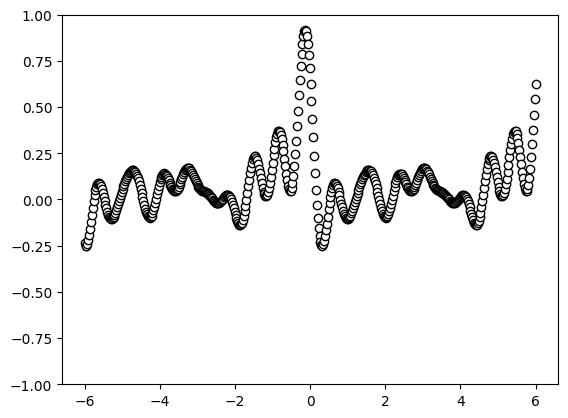

In [5]:
target_function = functions.function_to_learn(degree=10)

degree = 10  # degree of the target function
scaling = 1  # scaling of the data
coeffs = np.random.random(size=degree) + 1j * np.random.random(size=degree)  # coefficients of non-zero frequencies
# nomralize the coefficients so that the sum of the absolute values of the coefficients is 1
coeff0 = 0.1  # coefficient of zero frequency
coeffs = coeffs / np.sum(np.abs(coeffs))
coeffs = coeffs * (1 - coeff0) / 2  # scale the coefficients so that the sum of the absolute values of the coefficients is 1


dataset_size = 500
x = torch.linspace(-6, 6, dataset_size, requires_grad=False)
target_y = target_function(x)

plt.scatter(x, target_y, facecolor="white", edgecolor="black")
plt.ylim(-1, 1)
plt.show()

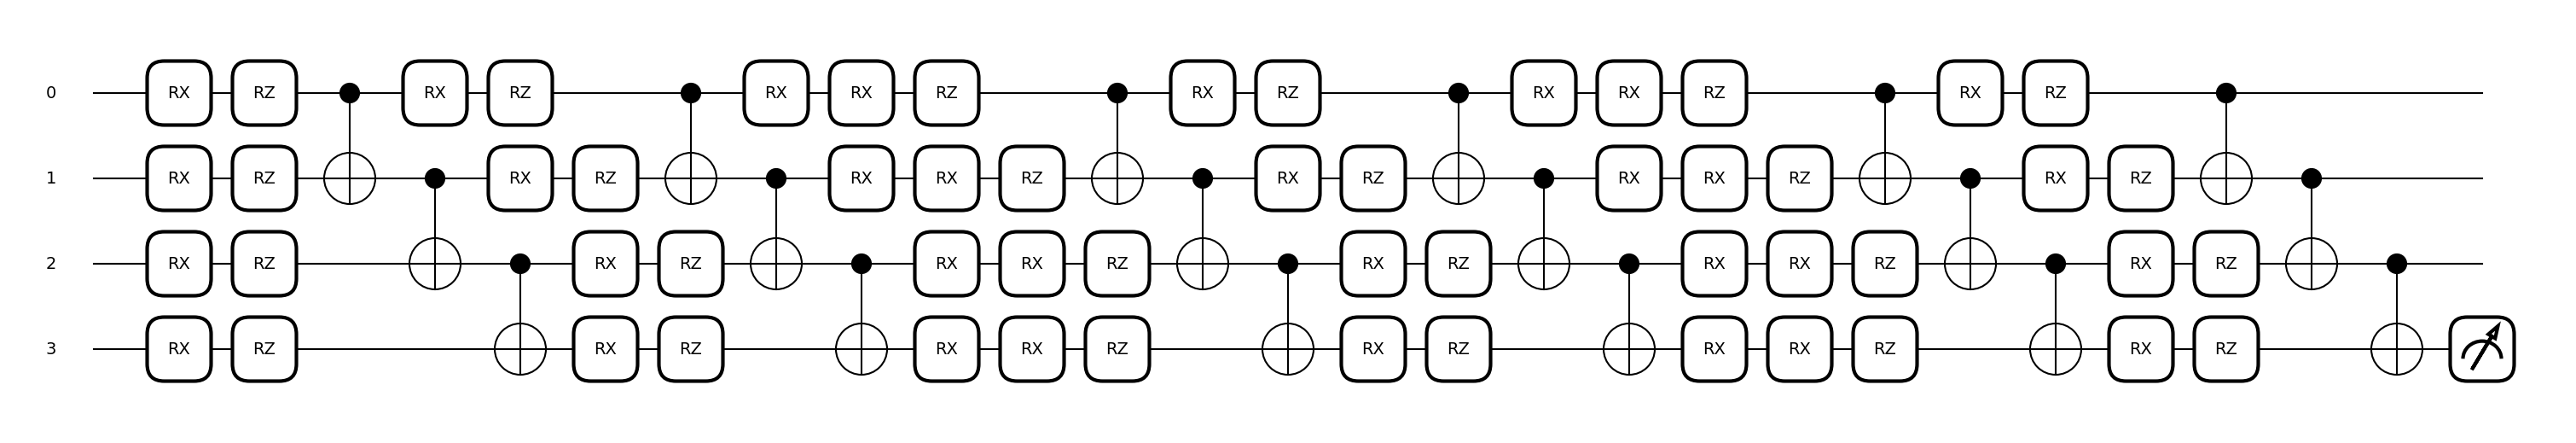

In [6]:
n_qubits = 4
layers = 3

num = 2  # circuit number to use

circuit, weights = functions.build_model(num, n_qubits, layers, anzats_reps=2, measuring_qubit=3)

qp.draw_mpl(circuit, level="device")(weights,0)
plt.show()

Cost at step  20: 0.012323092212186224
Cost at step  40: 0.007633452740293048
Cost at step  60: 0.006672061979392977
Cost at step  80: 0.005771073857258192
Cost at step 100: 0.0031227063919803196
Cost at step 120: 0.0017443535796549123
Cost at step 140: 0.0015598389908677184
Cost at step 160: 0.000952554906984645
Cost at step 180: 0.00048820746962787955
Cost at step 200: 0.00024124976830614466


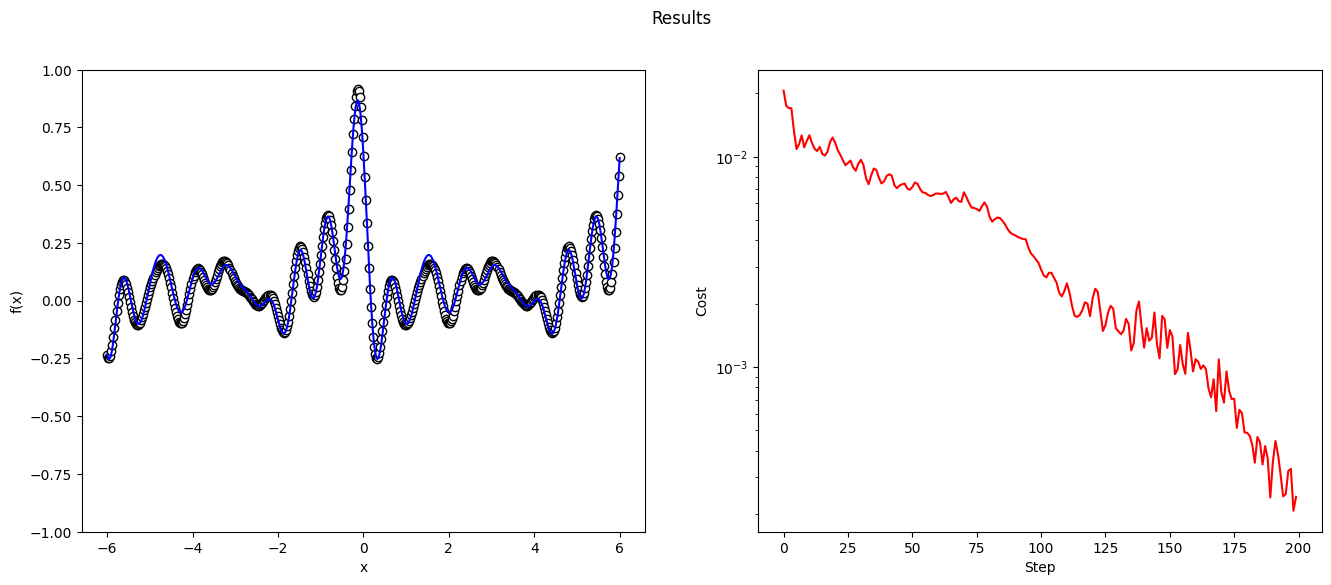

In [7]:
trained_weights, cst = functions.train(circuit, weights, x, target_y, max_steps=200, display_step=20)

functions.show_results(circuit,trained_weights, x, target_y, cst)

In [8]:
path = "../results/"

experiment_id, final_weights, cost_history = experiment_tracker.train_and_record(x, target_y, circuit_num=num, n_qubits=n_qubits, layers=layers, anzats_reps=2, path=path)

[tracker] Experiment c6c1f0df-dc62-4a34-b8c6-43974e14deb6 saved (circuit=2, qubits=4, layers=3, final_cost=0.000404)
